In [13]:
import random
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
import random
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
def get_sensor_data():
    current = random.randint(200, 800)
    voltage = random.randint(1200, 1700)
    temp = random.randint(300, 600)

    return {
        "current": current,
        "voltage": voltage,
        "temp": temp
    }

In [4]:
data = []

for i in range(300):
    d = get_sensor_data()

    # Improved labeling logic
    if d["current"] < 400 and d["temp"] < 450:
        label = 0   # low load
    elif d["current"] < 600:
        label = 1   # medium load
    else:
        label = 2   # high load

    d["label"] = label
    data.append(d)

df = pd.DataFrame(data)

df.head()

,current,voltage,temp,label
0,680,1574,337,2
1,724,1275,458,2
2,555,1568,394,1
3,433,1353,351,1
4,446,1509,326,1


In [5]:
df.to_csv("motor_data.csv", index=False)
print("Dataset saved as motor_data.csv")

Dataset saved as motor_data.csv


In [6]:
X = df[["current", "voltage", "temp"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 6  0  0]
 [ 0 31  0]
 [ 0  0 23]]


In [9]:
while True:
    data = get_sensor_data()

    # Convert to DataFrame (fix warning)
    input_df = pd.DataFrame([data])
    pred = model.predict(input_df)

    print("\n============================")
    print(f"Current: {data['current']}")
    print(f"Voltage: {data['voltage']}")
    print(f"Temperature: {data['temp']}")

    print("Predicted Load:", pred[0])

    # Simulated motor control
    if pred[0] == 0:
        speed = "LOW"
    elif pred[0] == 1:
        speed = "MEDIUM"
    else:
        speed = "HIGH"

    print("Motor Speed:", speed)

    time.sleep(1)


Current: 627
Voltage: 1334
Temperature: 377
Predicted Load: 2
Motor Speed: HIGH

Current: 553
Voltage: 1243
Temperature: 392
Predicted Load: 1
Motor Speed: MEDIUM

Current: 343
Voltage: 1485
Temperature: 347
Predicted Load: 0
Motor Speed: LOW

Current: 353
Voltage: 1591
Temperature: 378
Predicted Load: 0
Motor Speed: LOW

Current: 710
Voltage: 1693
Temperature: 411
Predicted Load: 2
Motor Speed: HIGH

Current: 668
Voltage: 1390
Temperature: 512
Predicted Load: 2
Motor Speed: HIGH

Current: 797
Voltage: 1611
Temperature: 338
Predicted Load: 2
Motor Speed: HIGH

Current: 453
Voltage: 1555
Temperature: 356
Predicted Load: 1
Motor Speed: MEDIUM

Current: 633
Voltage: 1676
Temperature: 448
Predicted Load: 2
Motor Speed: HIGH

Current: 208
Voltage: 1622
Temperature: 592
Predicted Load: 1
Motor Speed: MEDIUM

Current: 561
Voltage: 1398
Temperature: 325
Predicted Load: 1
Motor Speed: MEDIUM


KeyboardInterrupt: 

In [10]:
# Interrupt kernel OR restart kernel

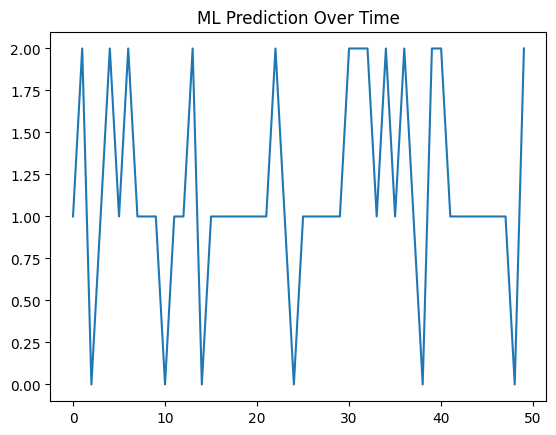

In [14]:
predictions = []

for i in range(50):
    data = get_sensor_data()
    input_df = pd.DataFrame([data])
    pred = model.predict(input_df)

    predictions.append(pred[0])

plt.plot(predictions, label="Predicted Load")
plt.title("ML Prediction Over Time")
plt.show()

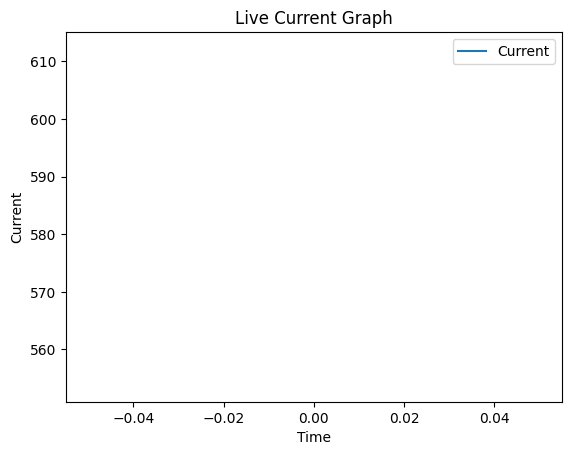

KeyboardInterrupt: 

In [15]:
import matplotlib.pyplot as plt
import time

plt.ion()

currents = []

fig, ax = plt.subplots()

for i in range(50):
    data = get_sensor_data()
    currents.append(data["current"])

    ax.clear()
    ax.plot(currents, label="Current")
    ax.set_title("Live Current Graph")
    ax.set_xlabel("Time")
    ax.set_ylabel("Current")
    ax.legend()

    plt.pause(0.5)

plt.ioff()
plt.show()

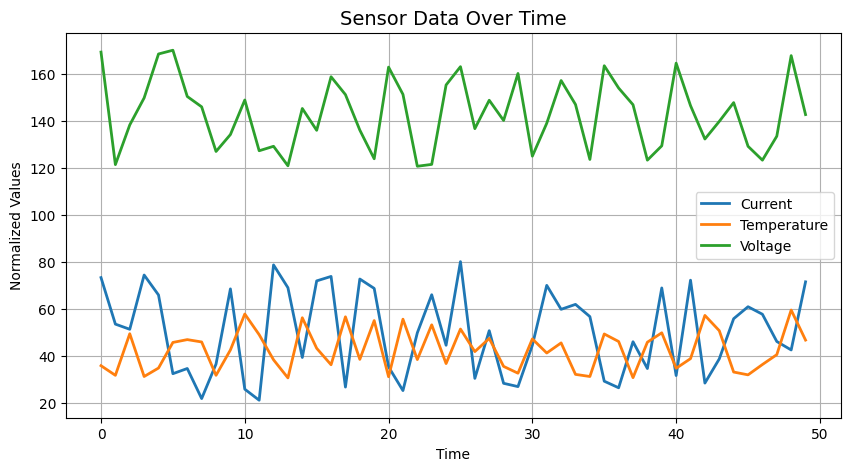

In [16]:
import matplotlib.pyplot as plt

currents = []
temps = []
voltages = []

for i in range(50):
    data = get_sensor_data()

    currents.append(data["current"]/10)
    temps.append(data["temp"]/10)
    voltages.append(data["voltage"]/10)



plt.figure(figsize=(10,5))

plt.plot(currents, label="Current", linewidth=2)
plt.plot(temps, label="Temperature", linewidth=2)
plt.plot(voltages, label="Voltage", linewidth=2)

plt.legend()
plt.title("Sensor Data Over Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Normalized Values")

plt.grid(True)
plt.show()

In [17]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!
